## **PROMOTE Sprint - Day 1**
### Tutorial: Getting Started with NEMO Cookbook

#### 13th July 2026

#### **Contact:**
Ollie Tooth (oliver.tooth@noc.ac.uk), National Oceanography Centre

#### **Background:**
---


NEMO Cookbook extends the familiar xarray data model with grid-aware data structures designed for performing reproducible analyses of the Nucleus for European Modelling of the Ocean ([**NEMO**](https://www.nemo-ocean.eu/)) ocean general circulation model outputs.

In these hands-on tutorials, we will use the `NEMODataTree` object to analyse ocean & sea-ice outputs of the UKESM1-2-LL TIPMIP idealised emissions scenarios and the CANARI Large-Ensemble.

We will cover:

* Creating `NEMODataTree` objects directly from netCDF files, including CMORISED outputs from coupled climate models, and from virtual Icechunk repositories.

* Exploring NEMO ocean & sea-ice variables stored in a `NEMODataTree`.

* Geographical plotting of `NEMODataArray`.

* Performing grid-aware operations using `NEMODataArray`.

#### **1.1 Creating NEMODataTrees**
---

* Let's begin by importing the **NEMO Cookbook** Python library and the `NEMODataTree` class:

In [1]:
import os

import cartopy.crs as ccrs
import icechunk
import matplotlib.pyplot as plt
import nemo_cookbook as ncb
import pandas as pd
import xarray as xr
from nemo_cookbook import NEMODataTree
from xarray.coders import CFDatetimeCoder

##### **1.1.1 Creating a NEMODataTree from Local Files**

* We'll begin by creating a simple `NEMODataTree` using local NEMO model output files from the `AGRIF_DEMO` reference configuration.

---

`AGRIF_DEMO`

* `AGRIF_DEMO` is based on the `ORCA2_ICE_PISCES` global reference configuration with the inclusion of 3 online nested domains.

* Here, we will only consider the 2° global parent domain.

* **NEMO Cookbook** includes a subset of the `AGRIF_DEMO` model outputs made accessible via cloud object storage.

* Further information on this reference configuration can be found [**here**](https://sites.nemo-ocean.io/user-guide/cfgs.html#agrif-demo).

---

* Let's download and collect the filepaths for the `AGRIF_DEMO` configuration using the `nemo_cookbook.examples.get_filepaths()` convenience function, which caches and generates local filepaths for available NEMO reference configurations:

In [2]:
filepaths = ncb.examples.get_filepaths("AGRIF_DEMO")
filepaths

{'domain_cfg.nc': '/home/users/o_tooth/.cache/nemo_cookbook/AGRIF_DEMO/domain_cfg.nc',
 '2_domain_cfg.nc': '/home/users/o_tooth/.cache/nemo_cookbook/AGRIF_DEMO/2_domain_cfg.nc',
 '3_domain_cfg.nc': '/home/users/o_tooth/.cache/nemo_cookbook/AGRIF_DEMO/3_domain_cfg.nc',
 'ORCA2_5d_00010101_00010110_grid_T.nc': '/home/users/o_tooth/.cache/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_grid_T.nc',
 'ORCA2_5d_00010101_00010110_grid_U.nc': '/home/users/o_tooth/.cache/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_grid_U.nc',
 'ORCA2_5d_00010101_00010110_grid_V.nc': '/home/users/o_tooth/.cache/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_grid_V.nc',
 'ORCA2_5d_00010101_00010110_grid_W.nc': '/home/users/o_tooth/.cache/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_grid_W.nc',
 'ORCA2_5d_00010101_00010110_icemod.nc': '/home/users/o_tooth/.cache/nemo_cookbook/AGRIF_DEMO/ORCA2_5d_00010101_00010110_icemod.nc',
 '2_Nordic_5d_00010101_00010110_grid_T.nc': '/home/users/o_tooth/.

* We can create a `NEMODataTree` from a dictionary of paths to local netCDF files using the `.from_paths()` constructor:

---

`from_paths()`

* Creates a `NEMODataTree` from a dictionary of paths to NEMO model outputs files organised into a hierarchy (e.g., `parent`, `child` `grandchild`) of NEMO model grids (e.g., `gridT`, `gridU`, etc.):
```
    <xarray.DataTree 'nemo'>
    Group: /
    ├── Group: /gridT
    ├── Group: /gridU
    ├── Group: /gridV
    ├── Group: /gridW
    └── Group: /gridF
```

where the `gridT` node contains time series of scalar variables stored in the `...grid_T.nc` files in a single `xarray.Dataset` and so on.

---

* Let's start by defining the `paths` dictionary, which contains the filepaths corresponding to our global parent domain.

* We populate the `parent` dictionary with the filepaths to the `domain_cfg` and `gridT/U/V/W` netCDF files produced for the `AGRIF_DEMO` (ORCA2) parent domain. 

In [3]:
paths = {"parent": {"domain": filepaths["domain_cfg.nc"],
                    "gridT": filepaths["ORCA2_5d_00010101_00010110_grid_T.nc"],
                    "gridU": filepaths["ORCA2_5d_00010101_00010110_grid_U.nc"],
                    "gridV": filepaths["ORCA2_5d_00010101_00010110_grid_V.nc"],
                    "gridW": filepaths["ORCA2_5d_00010101_00010110_grid_W.nc"],
                    "icemod": filepaths["ORCA2_5d_00010101_00010110_icemod.nc"]
                    },
         }

* We can now construct a new `NEMODataTree` using the `.from_paths()` constructor.

* **Note that we also need to specify that our global parent domain is zonally periodic (`iperio=True`) and north folding on T-points (`nftype = "T"`) rather than a closed (regional) domain.**

In [4]:
NEMODataTree.from_paths(paths, iperio=True, nftype="T", chunks={})

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 2, axis_nbounds: 2, ncatice: 5)
│   Coordinates:
│     * time_counter          (time_counter) object 16B 0001-01-03 12:00:00 0001-...
│       time_centered         (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
│       time_instant          (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
│     * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_instant_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   T
│       iperio:   True
├── Group: /gridT
│       Dimensions:               (k: 31, axis_nbounds: 2, time_counter: 2, j: 148,
│                                  i: 180, ncatice: 5)
│       Coordinates:
│         * k                     (k) int64 248B 1 2 3 4 5 6 7 ... 25 26 27 28 29 30 31
│         * deptht                (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
│           time_centered         (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
│           time_instant          (time_counter) object 16B dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                     (j) int64 1kB 1 2 3 4 5 6 ... 143 144 145 146 147 148
│         * i                     (i) int64 1kB 1 2 3 4 5 6 ... 175 176 177 178 179 180
│           gphit                 (j, i) float64 213kB ...
│           glamt                 (j, i) float64 213kB ...
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/85)
│           deptht_bounds         (k, axis_nbounds) float32 248B dask.array<chunksize=(31, 2), meta=np.ndarray>
│           time_centered_bounds  (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│           time_counter_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│           time_instant_bounds   (time_counter, axis_nbounds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
│           e3t                   (time_counter, k, j, i) float32 7MB dask.array<chunksize=(1, 31, 148, 180), meta=np.ndarray>
│           thetao                (time_counter, k, j, i) float32 7MB dask.array<chunksize=(1, 31, 148, 180), meta=np.ndarray>
│           ...                    ...
│           sisalcat              (time_counter, ncatice, j, i) float32 1MB dask.array<chunksize=(1, 5, 148, 180), meta=np.ndarray>
│           sitemcat              (time_counter, ncatice, j, i) float32 1MB dask.array<chunksize=(1, 5, 148, 180), meta=np.ndarray>
│           e1t                   (j, i) float64 213kB ...
│           e2t                   (j, i) float64 213kB ...
│           tmask                 (k, j, i) bool 826kB False False False ... False False
│           tmaskutil             (j, i) bool 27kB False False False ... False False
│       Attributes:
│           name:         ORCA2_5d_00010101_00010110_grid_T
│           description:  ocean T grid variables
│           title:        ocean T grid variables
│           Conventions:  CF-1.6
│           timeStamp:    2025-Sep-13 17:44:13 GMT
│           uuid:         92bd7786-afa1-44db-8a63-995c0e56d322
│           nftype:       T
│           iperio:       True
├── Group: /gridU
│       Dimensions:               (k: 31, axis_nbounds: 2, time_counter: 2, j: 148,
│                                  i: 180)
│       Coordinates:
│         * k                     (k) int64 248B 1 2 3 4 5 6 7 ... 25 26 27 28 29 30 31
│         * depthu                (k) float32 124B 5.0 15.0 25.0 ... 4.75e+03 5.25e+03
│           time_centered         (time_counter

##### **1.1.2 Creating a NEMODataTree from CMORISED Datasets**

* In addition to reading netCDF files directly, we can also create a `NEMODataTree` from a dictionary of `xarray.Datasets` using the `.from_datasets()` constructor:

---

`from_datasets()`

* Creates a `NEMODataTree` from a dictionary of `xarray.Datasets` organised into a hierarchy (e.g., `parent`, `child` `grandchild`) of NEMO model grids (e.g., `gridT`, `gridU`, etc.):

```
    <xarray.DataTree 'nemo'>
    Group: /
    ├── Group: /gridT
    ├── Group: /gridU
    ├── Group: /gridV
    ├── Group: /gridW
    └── Group: /gridF
```

where the `gridT` node contains time series of scalar variables stored in the input `xarray.Dataset` and so on.

---

* Here, we show how to construct a `NEMODataTree` from the 1° global ocean sea-ice component of **UKESM1-2-LL** using outputs accessible via the `terrafirma` group workspace.

* Since CMIP6 outputs are processed and formatted according to the CMIP Community Climate Model Output Rewriter (CMOR) software, we will need to include a few additional pre-processing steps to reformat our NEMO model outputs in order to construct a `NEMODataTree`

**Important: only CMIP model outputs variables stored on their original NEMO ocean model grid (i.e, `gn`) can be used to construct a `NEMODataTree`**

In [5]:
# -- Open UKESM1-2-LL domain_cfg -- #
ds_domain = xr.open_dataset("/gws/ssde/j25b/terrafirma/otooth/Ofx/domain_cfg_UKESM1.nc")

ds_domain

<xarray.Dataset> Size: 488MB
Dimensions:       (y: 330, x: 360, nav_lev: 75)
Dimensions without coordinates: y, x, nav_lev
Data variables: (12/47)
    nav_lon       (y, x) float32 475kB ...
    nav_lat       (y, x) float32 475kB ...
    time_counter  float64 8B ...
    tmask         (nav_lev, y, x) int8 9MB ...
    umask         (nav_lev, y, x) int8 9MB ...
    vmask         (nav_lev, y, x) int8 9MB ...
    ...            ...
    gdept_1d      (nav_lev) float64 600B ...
    gdepw_1d      (nav_lev) float64 600B ...
    e3t_1d        (nav_lev) float64 600B ...
    e3w_1d        (nav_lev) float64 600B ...
    wmask         (nav_lev, y, x) int8 9MB ...
    wmaskutil     (y, x) int8 119kB ...
Attributes:
    file_name:  mesh_mask.nc
    TimeStamp:  06/02/2026 10:14:02 +0000

In [6]:
# -- Create NEMO gridT dataset from UKESM1-2-LL -- #
# Define time decoder to handle CMIP6 time units:
time_decoder = xr.coders.CFDatetimeCoder(use_cftime=True)

# Open UKESM1-2-LL thetao dataset, including potential temperature (°C):
base_filepath = "/gws/ssde/j25b/terrafirma/TerraFIRMA/MOHC/UKESM1-2/esm-hist/r1i1p1f1/Omon"
ds_ukesm_gridT = xr.open_mfdataset(f"{base_filepath}/thetao/gn/v20240619/thetao_Omon_UKESM1-2-LL_esm-hist_r1i1p1f1_gn_*.nc",
                                   data_vars='all',
                                   decode_times=time_decoder
                                   )

# Adding UKESM1-2-LL thkcello dataset, including vertical cell thickness (m):
ds_ukesm_gridT['thkcello'] = xr.open_mfdataset(f"{base_filepath}/thkcello/gn/v20240619/thkcello_Omon_UKESM1-2-LL_esm-hist_r1i1p1f1_gn_*.nc",
                                               data_vars='all',
                                               decode_times=time_decoder
                                               )['thkcello']

# Rename variables to NEMO standard names:
ds_ukesm_gridT = ds_ukesm_gridT.rename({'time': 'time_counter',
                                        'i': 'x',
                                        'j': 'y',
                                        'lev': 'deptht',
                                        'thkcello': 'e3t'}
                                        )

ds_ukesm_gridT

<xarray.Dataset> Size: 156GB
Dimensions:             (time_counter: 1980, bnds: 2, deptht: 75, y: 330,
                         x: 360, vertices: 4)
Coordinates:
  * time_counter        (time_counter) object 16kB 1850-01-16 00:00:00 ... 20...
  * deptht              (deptht) float64 600B 0.5058 1.556 ... 5.902e+03
  * y                   (y) int32 1kB 0 1 2 3 4 5 6 ... 324 325 326 327 328 329
  * x                   (x) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (y, x) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude           (y, x) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time_counter, bnds) object 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lev_bnds            (time_counter, deptht, bnds) float64 2MB dask.array<chunksize=(600, 75, 2), meta=np.ndarray>
    vertices_latitude   (time_counter, y, x, vertices) float64 8GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
    vertices_longitude  (time_counter, y, x, vertices) float64 8GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
    thetao              (time_counter, deptht, y, x) float32 71GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
    e3t                 (time_counter, deptht, y, x) float32 71GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
Attributes: (12/39)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           TerraFIRMA
    branch_method:         no parent
    creation_date:         2024-06-01T20:31:24Z
    cv_version:            GCModelDev v0.0.17
    data_specs_version:    GCModelDev v0.0.17
    ...                    ...
    variable_id:           thetao
    variable_name:         thetao
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.7.3
    tracking_id:           GCMODELDEV/1bfb86d9-1d94-460f-a171-b9867c06603a

Now we have defined our `domain`, `gridT` and `gridU` datasets, let's define a `datasets` dictionary ensuring that we rename CMORISED dimensions to be consistent with standard NEMO model outputs.

**Note that we must rename the CMORISED variable `thkcello` to standard NEMO name `e3t`**

We can then define a `NEMODataTree` using the `.from_datasets()` constructor, specifying that our global parent domain is zonally periodic and north-folding on F-points.

**Note that we will still obtain a `NEMODataTree` with a complete set of grid nodes (i.e., `gridT`, `gridU`, etc.)**

In [7]:
datasets = {"parent": {"domain": ds_domain, "gridT": ds_ukesm_gridT}}

NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:       (time_counter: 1980, bnds: 2)
│   Coordinates:
│     * time_counter  (time_counter) object 16kB 1850-01-16 00:00:00 ... 2014-12-...
│   Dimensions without coordinates: bnds
│   Data variables:
│       time_bnds     (time_counter, bnds) object 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:             (time_counter: 1980, bnds: 2, k: 75, j: 330, i: 360,
│                                vertices: 4)
│       Coordinates:
│         * k                   (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
│         * deptht              (k) float64 600B 0.5058 1.556 ... 5.698e+03 5.902e+03
│         * j                   (j) int64 3kB 1 2 3 4 5 6 7 ... 325 326 327 328 329 330
│         * i                   (i) int64 3kB 1 2 3 4 5 6 7 ... 355 356 357 358 359 360
│           latitude            (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           longitude           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           gphit               (j, i) float32 475kB ...
│           glamt               (j, i) float32 475kB ...
│       Dimensions without coordinates: bnds, vertices
│       Data variables:
│           time_bnds           (time_counter, bnds) object 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│           lev_bnds            (time_counter, k, bnds) float64 2MB dask.array<chunksize=(600, 75, 2), meta=np.ndarray>
│           vertices_latitude   (time_counter, j, i, vertices) float64 8GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
│           vertices_longitude  (time_counter, j, i, vertices) float64 8GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
│           thetao              (time_counter, k, j, i) float32 71GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
│           e3t                 (time_counter, k, j, i) float32 71GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
│           e1t                 (j, i) float64 950kB ...
│           e2t                 (j, i) float64 950kB ...
│           tmask               (k, j, i) int8 9MB ...
│           tmaskutil           (j, i) int8 119kB ...
│       Attributes: (12/41)
│           Conventions:           CF-1.7 CMIP-6.2
│           activity_id:           TerraFIRMA
│           branch_method:         no parent
│           creation_date:         2024-06-01T20:31:24Z
│           cv_version:            GCModelDev v0.0.17
│           data_specs_version:    GCModelDev v0.0.17
│           ...                    ...
│           variant_label:         r1i1p1f1
│           license:               GCModelDev model data is licensed under the Open G...
│           cmor_version:          3.7.3
│           tracking_id:           GCMODELDEV/1bfb86d9-1d94-460f-a171-b9867c06603a
│           nftype:                F
│           iperio:                True
├── Group: /gridU
│       Dimensions:       (j: 330, i: 360, k: 75)
│       Coordinates:
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│           gphiu         (j, i) float32 475kB ...
│           glamu         (j, i) float32 475kB ...
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│       Data variables:
│           e1u           (j, i) float64 950kB ...
│           e2u           (j, i) float64 950kB ...
│           umask         (k, j, i) int8 9MB ...
│           umaskutil     (j, i) int8 119kB ...
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridV
│       Dimensions:       (j: 330, i: 360, k: 75)
│       Coordinates:
│         * j             (j) float64 3kB 1.5 2.5 3.5 4.5 ... 327.5 328.5 329.5 330.5
│         * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 35

##### **1.1.3 Virtual NEMODataTrees**

* Rather that having to merge *O*(100) - *O*(1000s) of netCDF files to create a `NEMODataTree` at the begining of every script, we can alternatively build a virtual `NEMODataTree`:

`Virtual NEMODataTree` -> lightweight, persistent map describing how to organise our netCDF files into a `NEMODataTree`.

* For the PROMOTE Analysis Sprint, we have created virtual `NEMODataTrees` for the following simulations:

    * **UKESM1-2-LL**: `/gws/ssde/j25b/terrafirma/otooth/repos/`

    * **CANARI-LE**: `/gws/ssde/j25b/canari/shared/large-ensemble/ocean/repos/`

* To access virtual `NEMODataTrees`, we can use the `.from_icechunk()` constructor:

---

`from_icechunk()`

* Creates a `NEMODataTree` from an Icechunk repository:

```
    <xarray.DataTree 'nemo'>
    Group: /
    ├── Group: /gridT
    ├── Group: /gridU
    ├── Group: /gridV
    ├── Group: /gridW
    └── Group: /gridF
```

where each grid node is stored as a virtual dataset in separate groups of a hierarchical Icechunk store.

---

* Here, we show how to construct a `NEMODataTree` from the 1° global ocean sea-ice component of **UKESM1-2-LL** using the available Icechunk repositories accessible via the `terrafirma` group workspace.

* Let's start by exploring the available Icechunk repositories...

In [8]:
os.listdir("/gws/ssde/j25b/terrafirma/otooth/repos/")

['UKESM1-2-LL_esm-hist_r1i1p1f1',
 'UKESM1-2-LL_esm-hist_r2i1p1f1',
 'UKESM1-2-LL_esm-hist_r3i1p1f1',
 'UKESM1-2-LL_esm-piControl_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl2p0-50y-dn1p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl2p0-50y-dn2p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl3p0-50y-dn2p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl4p0-50y-dn1p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl4p0-50y-dn2p0_r1i1p1f1']

In [9]:
os.listdir("/gws/ssde/j25b/canari/shared/large-ensemble/ocean/repos/")

['domain', 'SSP370', 'HIST1', 'HIST2']

* Next, let's define a reusable function `open_virtual_NEMODataTree()` to open a virtual `NEMODataTree` given the `experiment` and `member` of a UKESM1-2-LL simulation...

In [10]:
def open_virtual_NEMODataTree(
        experiment: str,
        member: str = "r1i1p1f1"
    ) -> NEMODataTree:

    # Authorise Icechunk to fetch virtual chunks from the original netCDF files on JASMIN terrafirma group workspace:
    store_fpath = "/gws/ssde/j25b/terrafirma"
    credentials = icechunk.credentials.containers_credentials({f"file://{store_fpath}/": icechunk.credentials.LocalFileSystemAccess})

    # Open Icechunk repository stored on JASMIN terrafirma group workspace:
    repo_fpath = f"/gws/ssde/j25b/terrafirma/otooth/repos/UKESM1-2-LL_{experiment}_{member}"
    repo = icechunk.Repository.open(storage=icechunk.local_filesystem_storage(repo_fpath),
                                    authorize_virtual_chunk_access=credentials
                                    )
    
    # Create virtual NEMODataTree from Icechunk repository:
    nemo = NEMODataTree.from_icechunk(repo=repo,
                                      branch="main",
                                      iperio=True,
                                      nftype="F",
                                      name=f"UKESM1-2-LL_{experiment}_{member}",
                                      open_kwargs={"decode_times": CFDatetimeCoder(time_unit="s"),
                                                   "chunks": {},
                                                   }
                                      )

    return nemo

In [11]:
# Open virtual NEMODataTree from UKESM1-2-LL esm-up2p0 Icechunk repository:
nemo = open_virtual_NEMODataTree(experiment="esm-up2p0", member="r1i1p1f1")

nemo

  2026-07-12T12:28:41.271769Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



<xarray.DataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
Group: /
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridF
│       Dimensions:       (j: 330, i: 360, k: 75, time_counter: 3480)
│       Coordinates:
│         * j             (j) float64 3kB 1.5 2.5 3.5 4.5 ... 327.5 328.5 329.5 330.5
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│           gphif         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           glamf         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
│       Data variables:
│           e1f           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           e2f           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           fmask         (k, j, i) int8 9MB dask.array<chunksize=(75, 330, 360), meta=np.ndarray>
│           fmaskutil     (j, i) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridW
│       Dimensions:       (j: 330, i: 360, k: 75, time_counter: 3480)
│       Coordinates:
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
│         * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
│           glamw         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           gphiw         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│         * k             (k) float64 600B 0.5 1.5 2.5 3.5 4.5 ... 71.5 72.5 73.5 74.5
│         * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
│       Data variables:
│           e2w           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           wmask         (k, j, i) int8 9MB dask.array<chunksize=(75, 330, 360), meta=np.ndarray>
│           wmaskutil     (j, i) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           e1w           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridT
│       Dimensions:       (time_counter: 3480, k: 75, j: 330, i: 360, bnds: 2)
│       Coordinates:
│         * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           deptht        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
│         * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
│           gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
│           glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
│       Dimensions without coordinates: bnds
│       Data variables: (12/26)
│           chl           (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
│           intpp         (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
│           hfds          (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
│           e1t           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           e2t           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           e3t           (time_counter, k, j, i)

#### **1.2 Navigating a NEMODataTree**
---

* Now we have created an example `NEMODataTree`, let's take a closer look at its contents and how to access NEMO model output variables.

* We'll start by looking at the nodes in our `NEMODataTree`:

In [12]:
nemo.groups

('/', '/gridF', '/gridW', '/gridT', '/gridV', '/gridU')

**Some Important Points:**

* A `NEMODataTree` does not have a `domain` node since grid scale factors and masks associated with each model domain are assigned to their respective grid nodes during pre-processing (e.g., horizontal grid scale factors `e1t` and `e2t` are stored in `gridT` etc.).

* During the construction of a `NEMODataTree`, the standard (`depth{p}`, `y`, `x`) dimensions of NEMO model outputs (where `p` is the grid point type) are transformed to NEMO grid indices (**i**, **j**, **k**). This has two important implications:

    * `xarray.Datasets` stored in each grid node share the same coordinate dimension names (`i`, `j`, `k`), but are staggered according to the location of variables on the NEMO model grid.

    * All grid indices use Fortran (1-based) indexing to be consistent with the original NEMO model code.

    | Grid Type    | Grid Indices                 |
    | -----------  | --------------------------   |
    | `T`          | $(i, j, k)$                    |
    | `U`          | $(i + \frac{1}{2}, j, k)$              |
    | `V`          | $(i, j + \frac{1}{2}, k)$              |
    | `W`          | $(i, j, k + \frac{1}{2})$              |
    | `F`          | $(i + \frac{1}{2}, j + \frac{1}{2}, k)$        |

---

* To see what this means in practice, we will consider the `gridT` and `gridU` nodes of the 2° `AGRIF_DEMO` `NEMODataTree` below:

In [13]:
nemo['gridT']

<xarray.DataTree 'gridT'>
Group: /gridT
    Dimensions:       (time_counter: 3480, k: 75, j: 330, i: 360, bnds: 2)
    Coordinates:
      * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
      * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
        deptht        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
      * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
      * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
        gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
        glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    Dimensions without coordinates: bnds
    Data variables: (12/26)
        chl           (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        intpp         (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        hfds          (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        e1t           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        e2t           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        e3t           (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        ...            ...
        sos           (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        zos           (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        tmask         (k, j, i) int8 9MB dask.array<chunksize=(75, 330, 360), meta=np.ndarray>
        simass        (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        talk          (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        si            (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
    Attributes: (12/38)
        Conventions:           CF-1.7 CMIP-6.2
        activity_id:           TerraFIRMA
        branch_method:         no parent
        cv_version:            GCModelDev v0.0.17
        data_specs_version:    GCModelDev v0.0.17
        experiment:            unknown
        ...                    ...
        variable_name:         tos
        variant_label:         r1i1p1f1
        license:               GCModelDev model data is licensed under the Open G...
        cmor_version:          3.7.3
        nftype:                F
        iperio:                True

In [14]:
nemo['gridU']

<xarray.DataTree 'gridU'>
Group: /gridU
    Dimensions:       (j: 330, i: 360, k: 75, time_counter: 3480, bnds: 2)
    Coordinates:
      * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
      * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
        glamu         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
        longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
        gphiu         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
      * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
        depthu        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
      * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
    Dimensions without coordinates: bnds
    Data variables:
        e2u           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        umask         (k, j, i) int8 9MB dask.array<chunksize=(75, 330, 360), meta=np.ndarray>
        umaskutil     (j, i) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        e1u           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        lev_bnds      (time_counter, k, bnds) float64 4MB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
        uo            (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        umo           (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        tauuo         (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
    Attributes: (12/37)
        Conventions:           CF-1.7 CMIP-6.2
        activity_id:           TerraFIRMA
        branch_method:         no parent
        cv_version:            GCModelDev v0.0.17
        data_specs_version:    GCModelDev v0.0.17
        experiment:            unknown
        ...                    ...
        variable_name:         tauuo
        variant_label:         r1i1p1f1
        license:               GCModelDev model data is licensed under the Open G...
        cmor_version:          3.7.3
        nftype:                F
        iperio:                True

* Above, we have seen how to access the nodes in an `NEMODataTree` using a dictionary-like syntax.

* We can also extend this to include output variables stored in given grid node as follows...

* To access an **unmasked** variable (i.e., unchanged from the original model output files) as an `xarray.DataArray`:

In [15]:
nemo['gridT']['thetao']

<xarray.DataArray 'thetao' (time_counter: 3480, k: 75, j: 330, i: 360)> Size: 124GB
dask.array<open_dataset-thetao, shape=(3480, 75, 330, 360), dtype=float32, chunksize=(1, 38, 165, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    deptht        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
  * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
  * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        mo: This variable is reported using a z* coordinate syste...
    units:          degC
    original_name:  mo: (variable_name: thetao)
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello

* To access a **unmasked** variable as a `NEMODataArray` (i.e.,  NEMO grid-aware extension of `xarray.DataArray`), we can instead provide a direct path to the variable:

In [16]:
nemo["gridT/thetao"]

<NEMODataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
  <NEMODataArray 'thetao' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'thetao' (time_counter: 3480, k: 75, j: 330, i: 360)> Size: 124GB
dask.array<open_dataset-thetao, shape=(3480, 75, 330, 360), dtype=float32, chunksize=(1, 38, 165, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    deptht        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
  * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
  * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        mo: This variable is reported using a z* coordinate syste...
    units:          degC
    original_name:  mo: (variable_name: thetao)
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello

* To access a **masked** (i.e., the appropriate land-sea mask is applied automatically) variable as an `NEMODataArray`, we can instead provide a direct path to the variable:

In [17]:
nemo["gridT/thetao"].masked

<NEMODataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
  <NEMODataArray 'thetao' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'thetao' (time_counter: 3480, k: 75, j: 330, i: 360)> Size: 124GB
dask.array<where, shape=(3480, 75, 330, 360), dtype=float32, chunksize=(1, 38, 165, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    deptht        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
  * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
  * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        mo: This variable is reported using a z* coordinate syste...
    units:          degC
    original_name:  mo: (variable_name: thetao)
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello

#### **1.3 NEMODataTree Grid Properties**
---

* We often need access to variables describing the NEMO ocean model domain to calculate derived quantities, such as volume, heat and salt transports.

* For convenience, the `NEMODataTree` class includes methods for calculating grid cell areas and volumes.

* For example, to compute the horizontal area of grid cells centered on T-points in the parent domain, we can use the `.cell_area()` method:

---

`cell_area()`

* The `dim` argument represents the dimensional orthogonal to the grid cell area to be computed.

* For **T** grid points, this results in the following grid cell areas: 

    | dim   | Grid Cell Area           |
    | ----------- | ---------------------- |
    | `i`         | e2t * e3t             |
    | `j`         | e1t * e3t        |
    | `k`         | e1t * e2t        |

---

In [18]:
nemo.cell_area(grid="gridT", dim="k")

<xarray.DataArray 'areacello' (j: 330, i: 360)> Size: 950kB
dask.array<mul, shape=(330, 360), dtype=float64, chunksize=(330, 360), chunktype=numpy.ndarray>
Coordinates:
  * j          (j) int64 3kB 1 2 3 4 5 6 7 8 ... 323 324 325 326 327 328 329 330
  * i          (i) int64 3kB 1 2 3 4 5 6 7 8 ... 353 354 355 356 357 358 359 360
    gphit      (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude   (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    glamt      (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude  (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>

* Next, let's compute the volume of each grid cell centered on a T grid point in the model parent domain using the `.cell_volume()` method:

In [19]:
nemo.cell_volume(grid="gridT")

<xarray.DataArray 'volcello' (time_counter: 3480, k: 75, j: 330, i: 360)> Size: 248GB
dask.array<mul, shape=(3480, 75, 330, 360), dtype=float64, chunksize=(1, 38, 165, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    deptht        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
  * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
  * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
Attributes:
    standard_name:  cell_thickness
    long_name:      Ocean Model Cell Thickness
    comment:        mo: This variable is reported using a z* coordinate syste...
    units:          m
    original_name:  mo: (variable_name: thkcello)
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello

#### **1.4 NEMODataArray Properties**
---

* In addition to simply storing ocean model output variable, a `NEMODataArray` also gives each variable knowledge of its:

    - NEMO model grid location (e.g., T, U, V, W, F)
    - parent `NEMODataTree`
    - associated NEMO grid metrics (grid scale factors)

--- 

* Each `NEMODataArray` has several key properties to support grid-aware computation...

    - `.data`  Underlying xarray.DataArray of the NEMO output variable.

    - `.grid`  Path to NEMO model grid node where variable is stored.

    - `.grid_type`  Type of NEMO model grid where variable is defined.

    - `.metrics`  Dictionary of NEMO model grid scale factors (e.g., e1t, e2t etc.) associated with the variable.

    - `.mask`  Variable land-sea mask (xarray.DataArray).

    - `.masked`  Returns variable NEMODataArray with land-sea mask applied.


In [20]:
# Collect grid scale factors of sea water potential temperature (thetao) variable on T-grid:
nemo['gridT/thetao'].metrics

{'e1': <NEMODataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
   <NEMODataArray 'e1t' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>
 
 <xarray.DataArray 'e1t' (j: 330, i: 360)> Size: 950kB
 dask.array<open_dataset-e1t, shape=(330, 360), dtype=float64, chunksize=(330, 360), chunktype=numpy.ndarray>
 Coordinates:
   * j          (j) int64 3kB 1 2 3 4 5 6 7 8 ... 323 324 325 326 327 328 329 330
   * i          (i) int64 3kB 1 2 3 4 5 6 7 8 ... 353 354 355 356 357 358 359 360
     gphit      (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
     latitude   (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
     glamt      (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
     longitude  (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>,
 'e2': <NEMODataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
   <NEMODataArray 'e2t' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>
 
 <xarray.DataArray 'e2t' (j: 330, i: 360)> Size: 950kB

In [21]:
# Collect land-sea mask of sea water potential temperature (thetao) variable on T-grid:
nemo['gridT/thetao'].mask

<xarray.DataArray 'tmask' (k: 75, j: 330, i: 360)> Size: 9MB
dask.array<open_dataset-tmask, shape=(75, 330, 360), dtype=int8, chunksize=(75, 330, 360), chunktype=numpy.ndarray>
Coordinates:
  * k          (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 67 68 69 70 71 72 73 74 75
    deptht     (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
  * j          (j) int64 3kB 1 2 3 4 5 6 7 8 ... 323 324 325 326 327 328 329 330
  * i          (i) int64 3kB 1 2 3 4 5 6 7 8 ... 353 354 355 356 357 358 359 360
    gphit      (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude   (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    glamt      (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude  (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>

#### **1.5 NEMODataArray Core Operations**

---

**Summary of Core Operations**

* Plotting:  `geoplot()`

* Indexing:  `sel_like()`

* Clipping & Masking:  `clip()`, `apply_mask()`

* Grid Operators:  `diff()`, `derivative()`, `integral()`, `depth_integral()`.

* Statistics:  `weighted_mean()`, `masked_statistic()`.

* Grid Transformations:  `interp_to()`, `transform_vertical_grid()`.

* For more details on the above core operations see the follow section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/).

---

#### **1.5.0 Plotting**

---

* Since `NEMODataArray` is a wrapper around the familiar `xarray.DataArray`, we can still access `xarray.DataArray.plot` for exploratory plotting.

* However, for geographical plots of 2-dimensional `NEMODataArrays` with dimensions (`j`, `i`) only, we can use the `geoplot()` method to produce a Cartopy `GeoQuadMesh` as follows:

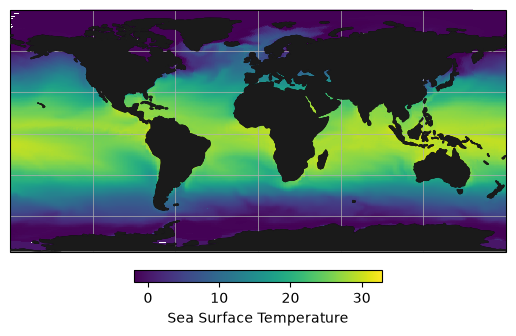

In [22]:
# -- Plot example sea surface temperature (°C) -- #
nemo["gridT/tos"].isel(time_counter=0).geoplot()

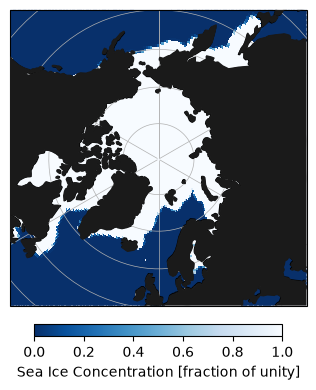

In [23]:
# -- Plot example sea ice concentration in the Northern Hemisphere -- #
proj = ccrs.NorthPolarStereo()

(nemo["gridT/siconc"]
 .isel(time_counter=0)
 .geoplot(projection=proj,
          vmin=0, vmax=1,
          extent=(-180, 180, 50, 90),
          cmap='Blues_r',
          clabel_kwargs={'label': 'Sea Ice Concentration [fraction of unity]'}
          )
 )

#### **1.5.1 Indexing**

---

* Alongside the more familiar `.sel()` and `.isel()` label based selection methods, the `.sel_like()` method can be used to index a `NEMODataArray` according to the dimension index labels of another `NEMODataArray` or `xarray.DataArray` as follows:

In [24]:
nda = nemo["gridT/thetao"].sel(i=slice(1, 90), k=20)

nemo["gridT/thetao"].sel_like(nda)

<NEMODataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
  <NEMODataArray 'thetao' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'thetao' (time_counter: 3480, j: 330, i: 90)> Size: 413MB
dask.array<getitem, shape=(3480, 330, 90), dtype=float32, chunksize=(1, 165, 90), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
  * i             (i) int64 720B 1 2 3 4 5 6 7 8 9 ... 83 84 85 86 87 88 89 90
    gphit         (j, i) float32 119kB dask.array<chunksize=(330, 90), meta=np.ndarray>
    latitude      (j, i) float64 238kB dask.array<chunksize=(165, 90), meta=np.ndarray>
    glamt         (j, i) float32 119kB dask.array<chunksize=(330, 90), meta=np.ndarray>
    longitude     (j, i) float64 238kB dask.array<chunksize=(165, 90), meta=np.ndarray>
    deptht        float64 8B dask.array<chunksize=(), meta=np.ndarray>
    k             int64 8B 20
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        mo: This variable is reported using a z* coordinate syste...
    units:          degC
    original_name:  mo: (variable_name: thetao)
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello

* We can also use the `add_geoindex()` method of our `NEMODataTree` to enable indexing of a NEMO model variables with geographical coordinates:

**Note that the `.dataset` property must be used to access the `xarray.Dataset` view of the NEMO model grid node**

In [25]:
nemo_geo = nemo.add_geoindex(grid="gridT")

nemo_geo["gridT"].dataset.sel(gphit=60, glamt=-40, method="nearest")

<xarray.Dataset> Size: 14MB
Dimensions:       (time_counter: 3480, k: 75, bnds: 2)
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    deptht        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
    i             int64 8B 249
    j             int64 8B 274
    latitude      float64 8B dask.array<chunksize=(), meta=np.ndarray>
    longitude     float64 8B dask.array<chunksize=(), meta=np.ndarray>
    gphit         float32 4B dask.array<chunksize=(), meta=np.ndarray>
    glamt         float32 4B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables: (12/26)
    chl           (time_counter, k) float32 1MB dask.array<chunksize=(1, 38), meta=np.ndarray>
    intpp         (time_counter) float32 14kB dask.array<chunksize=(1,), meta=np.ndarray>
    hfds          (time_counter) float32 14kB dask.array<chunksize=(1,), meta=np.ndarray>
    e1t           float64 8B dask.array<chunksize=(), meta=np.ndarray>
    e2t           float64 8B dask.array<chunksize=(), meta=np.ndarray>
    e3t           (time_counter, k) float32 1MB dask.array<chunksize=(1, 38), meta=np.ndarray>
    ...            ...
    sos           (time_counter) float32 14kB dask.array<chunksize=(1,), meta=np.ndarray>
    zos           (time_counter) float32 14kB dask.array<chunksize=(1,), meta=np.ndarray>
    tmask         (k) int8 75B dask.array<chunksize=(75,), meta=np.ndarray>
    simass        (time_counter) float32 14kB dask.array<chunksize=(1,), meta=np.ndarray>
    talk          (time_counter, k) float32 1MB dask.array<chunksize=(1, 38), meta=np.ndarray>
    si            (time_counter, k) float32 1MB dask.array<chunksize=(1, 38), meta=np.ndarray>
Attributes: (12/38)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           TerraFIRMA
    branch_method:         no parent
    cv_version:            GCModelDev v0.0.17
    data_specs_version:    GCModelDev v0.0.17
    experiment:            unknown
    ...                    ...
    variable_name:         tos
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.7.3
    nftype:                F
    iperio:                True

#### **1.5.2 Clipping & Masking**

---

* We often want to perform a calculation using only NEMO grid points within a specific region.

* To clip a `NEMODataArray` to include only data within a geographical bounding box, we can use the `clip()` method.


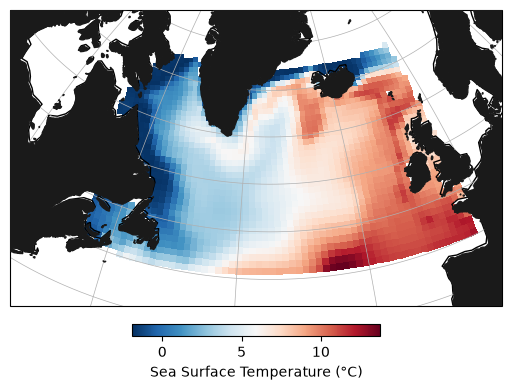

In [26]:
# Define subpolar North Atlantic boundary box for analysis:
bbox_spna = (-68, -2, 45, 67)  # (-68°E, -2°E, 45°N, 67°N)

# Plot the sea surface temperature (°C) in the subpolar North Atlantic region:
(nemo["gridT/tos"]
 .clip(bbox_spna)
 .isel(time_counter=0)
 .geoplot(projection=ccrs.Orthographic(central_longitude=-35, central_latitude=50),
          extent=(-75, 0, 42, 70), # (-75°E, -0°E, 42°N, 70°N)
          cmap='RdBu_r',
          clabel_kwargs={'label': 'Sea Surface Temperature (°C)'}
          )
 )

* To define a regional mask using the geographical coordinates of a closed polygon, we can use the `mask_with_polygon()` method.

* In this example, we use the IHO World Seas v3 Labrador Sea polygon to generate the longitude and latitude coordinates of the closed polygon to mask.

In [27]:
# Open IHO World Seas v3 polygons from JASMIN Object Store as Pandas DataFrame:
filepaths = ncb.examples.get_filepaths("IHO")

df_IHO_World_Seas = pd.read_parquet(filepaths['IHO_World_Seas_v3_polygons.parquet'])


# Define IHO World Seas Labrador Sea polygon:
lon_poly = df_IHO_World_Seas[df_IHO_World_Seas['Name'] == 'Labrador Sea']['Longitudes'].item()[0]
lat_poly = df_IHO_World_Seas[df_IHO_World_Seas['Name'] == 'Labrador Sea']['Latitudes'].item()[0]

# Define boolean mask for Labrador Sea:
LSea_mask = nemo.mask_with_polygon(grid='gridT', lon_poly=lon_poly, lat_poly=lat_poly)

LSea_mask

<xarray.DataArray (j: 330, i: 360)> Size: 119kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(330, 360))
Dimensions without coordinates: j, i

* Next, let's create a plot applying our regional mask to a given `NEMODataArray` variable using the `apply_mask()` method.

**Note that using `apply_mask()` is preferred over `where()` since this automatically applies the appropriate land-sea mask in addition to our custom mask**

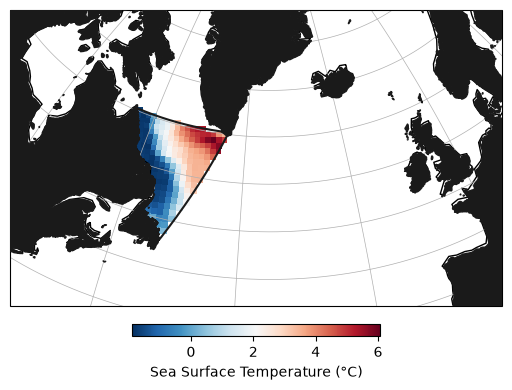

In [28]:
# Plotting Labrador Sea sub-domain sea surface temperature:
(nemo['gridT/tos']
 .isel(time_counter=0)
 .apply_mask(LSea_mask)
 .geoplot(projection=ccrs.Orthographic(central_longitude=-35, central_latitude=50),
          extent=(-75, 0, 42, 70), # (-75°E, -0°E, 42°N, 70°N)
          cmap='RdBu_r',
          clabel_kwargs={'label': 'Sea Surface Temperature (°C)'}
          )
 )

# Add IHO World Seas Labrador Sea polygon:
plt.plot(lon_poly, lat_poly, transform=ccrs.PlateCarree(), color='0.1', linewidth=1.5)

* For more details on clipping grids and domains within a `NEMODataTree` see the following section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#clip-a-nemo-model-grid).

#### **1.5.3 Grid Operators**

---

* Grid operators are the foundational set of finite difference operators defined on the NEMO model grid.

* For example, the difference operator $\delta_{i} [q]$ defined by:

$$\delta_{i} [q] = q(i + 1/2) - q(i - 1/2)$$

* For a complete list of grid operators implemented in NEMO Cookbook, see the following sections of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#calculate-horizontal-derivatives).

* Here, we will focus on the `integral()` method, which can be used to integrate a variable `var` along one or more dimensions `dims` of a given NEMO model grid `grid`.

* As an example, let's compute the total March mixed layer volume in the subpolar North Atlantic in esm-up2p0...

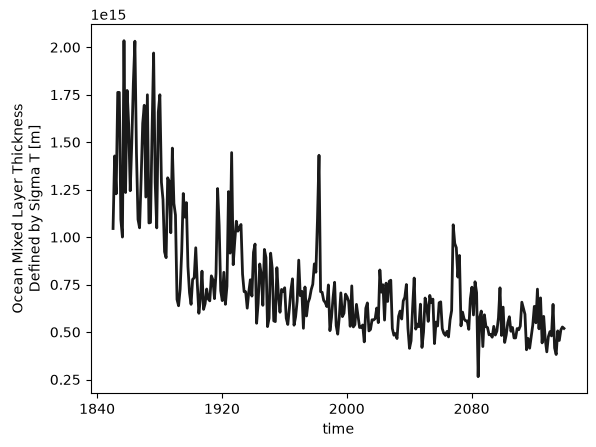

In [29]:
(nemo["gridT/mlotst"]
 # Select only March months:
 .sel(time_counter=nemo["gridT/time_counter"].dt.month == 3)
 # Clip to the SPNA bbox (-68°E, -2°E, 45°N, 67°N):
 .clip(bbox_spna)
 # Calculate area integral of mixed layer depth (m -> m³) in the SPNA:
 .integral(dims=["i", "j"])
 # Plot March mixed layer volume in the SPNA (m³):
 .plot(linewidth=2, color='0.1')
 )

* We can also use the `.integral()` method to calculate cumulative integrals along one or more dimensions of a given NEMO model grid.

* For more details on cumulative integration see the following section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#calculate-cumulative-integrals).

#### **1.5.4 Grid Transformations**
---

* Given that scalar and vector NEMO output variables are not co-located on the model grid, we often need to transform a variable defined on a given NEMO horizontal grid to a neighbouring grid via linear interpolation.

* For example, we can transform the seawater potential temperature `thetao` defined on scalar **T**-points to neighbouring **V**-points in a NEMO model parent domain using the `.interp_to()` method:

In [30]:
nemo['gridT/thetao'].interp_to(to='V')

<NEMODataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
  <NEMODataArray 'thetao' (Domain: '.', Grid: 'gridV', Grid Type: 'V')>

<xarray.DataArray 'thetao' (time_counter: 3480, k: 75, j: 330, i: 360)> Size: 248GB
dask.array<where, shape=(3480, 75, 330, 360), dtype=float64, chunksize=(1, 38, 165, 180), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    depthv        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
  * j             (j) float64 3kB 1.5 2.5 3.5 4.5 ... 327.5 328.5 329.5 330.5
  * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    glamv         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    gphiv         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        mo: This variable is reported using a z* coordinate syste...
    units:          degC
    original_name:  mo: (variable_name: thetao)
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello

**Note that the original T-grid coordinate variables have been replaced by those of the V-grid onto which the conservative temperature field has been linearly interpolated.**

* We can also transform a variable defined on a given NEMO model vertical grid to a new vertical grid using conservative interpolation via the `.transform_vertical_grid()` method.

* For more details on vertical grid transformations see the following section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#interpolate-variable-to-a-neighbouring-horizontal-grid).

#### **1.5.5 Statistics**
---

* Finally, we often want to calculate grid-aware statistics, such as area-weighted averages, using our NEMO model outputs.

* Here, we leverage method chaining and the `weighted_mean()` method to calculate the horizontal grid cell area-weighted average sea surface temperature in the Northern Hemisphere:

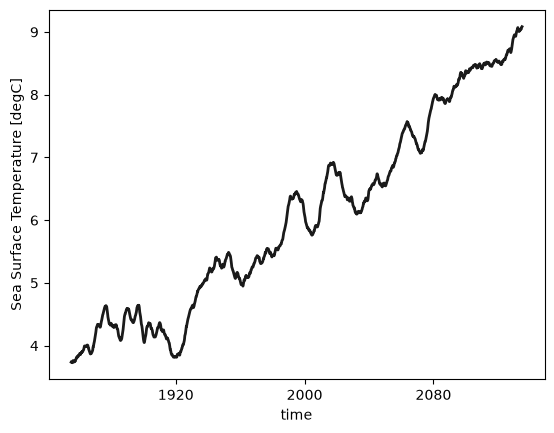

In [31]:
# Calculate the area weighted-mean sea surface temperature in the Labrador Sea:
tos_LSea_wmean = nemo["gridT/tos"].apply_mask(LSea_mask).weighted_mean(dims=["i", "j"])

(tos_LSea_wmean
 .rolling(time_counter=120, center=True) # -> 120-month rolling average.
 .mean()
 .plot(linewidth=2, color='0.1')
)

* We can also calculate aggregated statistics of a variable binned according to the values of one or more variables using the `NEMODataTree.binned_statistic()` method.

* For more details on statistical methods see the following section of the [**How To... Guide**](https://noc-msm.github.io/nemo_cookbook/howto/#calculate-statistics-for-a-region-masked-using-a-polygon).